In [5]:
import pandas as pd
import re

df_raw = pd.read_excel('Tension Test_VIT_re.xlsx')

def filter_age(row):
    text = (str(row['Mixture']) + " " + str(row['Specimen'])).lower()
    match = re.search(r'(\d+)\s*day', text)
    if match:
        return int(match.group(1)) != 28
    return False

def filter_loading(row):
    text = (str(row['Mixture']) + " " + str(row['Specimen'])).lower()
    return "load" in text

df_raw['drop_flag'] = df_raw.apply(lambda r: filter_age(r) or filter_loading(r), axis=1)
df_filtered = df_raw[df_raw['drop_flag'] == False].copy()

cols_to_remove = [
    'Mixture', 'Specimen', 'Coarse Aggr.',
    'Fly ash C', 'Fiber Type', 'drop_flag'
]
df_dropped = df_filtered.drop(columns=[c for c in cols_to_remove if c in df_filtered.columns])

features = [c for c in df_dropped.columns if c not in ['Second Stress', 'Second Strain']]
df_final = df_dropped.groupby(features, as_index=False).mean()

df_final.to_csv('ECC_An_Final_Simplified.csv', index=False)
print(f"Reduced {len(df_raw)} og rows to {len(df_final)} final rows.")

Reduced 659 og rows to 282 final rows.


Features active: 17 columns
Stress R^2 : 0.7718
Strain R^2 : 0.5774


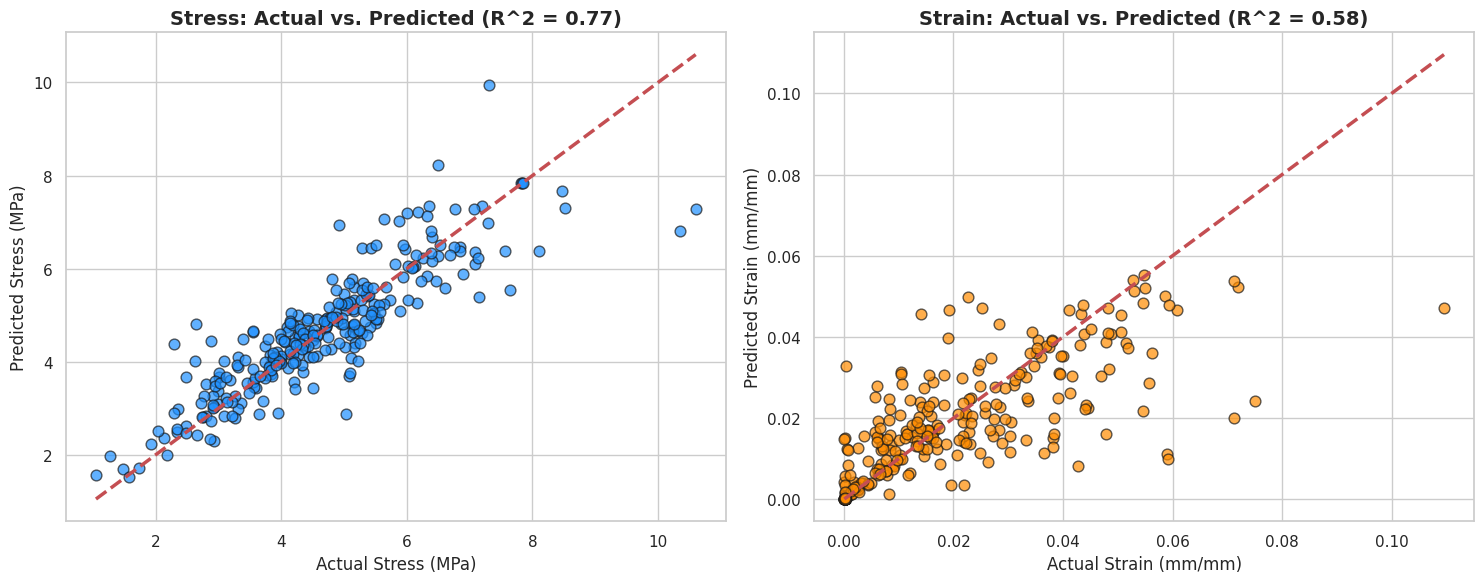

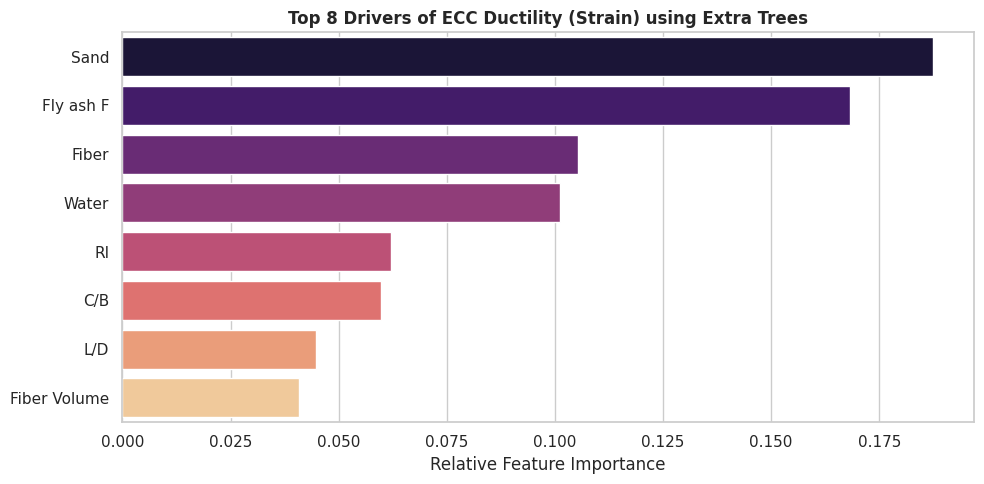

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.metrics import r2_score
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import TransformedTargetRegressor


df = pd.read_csv('ECC_An_Final_Simplified.csv')

X = df.drop(columns=['Second Stress', 'Second Strain'])
y_stress = df['Second Stress']
y_strain = df['Second Strain']

X = X.loc[:, (X != 0).any(axis=0)]
print(f"Features active: {len(X.columns)} columns")

scaler = StandardScaler()
pipe_stress = Pipeline([
    ('scaler', scaler),
    ('model', ExtraTreesRegressor(n_estimators=100, random_state=42))
])

pipe_strain = Pipeline([
    ('scaler', scaler),
    ('model', TransformedTargetRegressor(
        regressor=ExtraTreesRegressor(
            n_estimators=100,
            min_samples_split=4,   # Tuned to prevent overfitting on sparse data
            max_depth=20,          # Tuned to generalize better
            random_state=42
        ),
        transformer=PowerTransformer(method='yeo-johnson')
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

stress_preds = cross_val_predict(pipe_stress, X, y_stress, cv=kf)
strain_preds = cross_val_predict(pipe_strain, X, y_strain, cv=kf)
stress_r2 = r2_score(y_stress, stress_preds)
strain_r2 = r2_score(y_strain, strain_preds)

print(f"Stress R^2 : {stress_r2:.4f}")
print(f"Strain R^2 : {strain_r2:.4f}")




sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_stress, stress_preds, alpha=0.7, color='dodgerblue', edgecolor='k', s=60)
axes[0].plot([y_stress.min(), y_stress.max()], [y_stress.min(), y_stress.max()], 'r--', lw=2.5)
axes[0].set_title(f"Stress: Actual vs. Predicted (R^2 = {stress_r2:.2f})", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Actual Stress (MPa)", fontsize=12)
axes[0].set_ylabel("Predicted Stress (MPa)", fontsize=12)

# Strain Plot
axes[1].scatter(y_strain, strain_preds, alpha=0.7, color='darkorange', edgecolor='k', s=60)
axes[1].plot([y_strain.min(), y_strain.max()], [y_strain.min(), y_strain.max()], 'r--', lw=2.5)
axes[1].set_title(f"Strain: Actual vs. Predicted (R^2 = {strain_r2:.2f})", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Actual Strain (mm/mm)", fontsize=12)
axes[1].set_ylabel("Predicted Strain (mm/mm)", fontsize=12)

plt.tight_layout()
plt.show()


pipe_strain.fit(X, y_strain)
importances = pipe_strain.named_steps['model'].regressor_.feature_importances_
fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=fi_df.head(8), x='Importance', y='Feature', palette='magma')
plt.title("Top 8 Drivers of ECC Ductility (Strain) using Extra Trees", fontweight='bold')
plt.xlabel("Relative Feature Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()